In [1]:
URL = " https://noaaocm.blob.core.windows.net/ais/csv2/csv2025/ais-2025-01-08.csv.zst"

In [13]:
import pandas as pd
df = pd.read_csv(URL)

In [14]:
#Set the index to the base_date_time. Your index should be a DateTimeIndex
df['base_date_time'] = pd.to_datetime(df['base_date_time'])
df.set_index("base_date_time",inplace=True)
df

,mmsi,longitude,latitude,sog,cog,heading,vessel_name,imo,call_sign,vessel_type,status,length,width,draft,cargo,transceiver
base_date_time,,,,,,,,,,,,,,,,
2025-01-08 00:00:00,367793030,-122.40506,47.68588,4.6,155.5,NaN,WN1622SL,NaN,WDJ5962,37.0,NaN,10.0,3.0,NaN,NaN,B
2025-01-08 00:00:00,338160209,-119.69199,34.40719,0.0,106.3,NaN,WESTERLY,NaN,NaN,36.0,NaN,11.0,4.0,NaN,NaN,B
2025-01-08 00:00:01,266283000,-74.24126,38.41834,15.5,187.9,190.0,OBERON,IMO9377509,SKJF,70.0,0.0,237.0,32.0,9.1,70.0,A
2025-01-08 00:00:10,368013620,-74.04712,40.10181,0.0,252.3,NaN,MARKET PRICE,NaN,WDJ8153,30.0,NaN,17.0,6.0,NaN,NaN,B
2025-01-08 00:00:09,368144150,-119.22453,34.16235,0.0,169.6,NaN,SILENT LADY,NaN,WDL5759,37.0,NaN,12.0,5.0,NaN,NaN,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-08 18:58:42,368920000,144.66472,13.42224,0.0,NaN,149.0,HENSON,IMO9132129,NENB,35.0,5.0,100.0,18.0,NaN,35.0,A
2025-01-08 19:49:42,368920000,144.66471,13.42224,0.0,NaN,149.0,HENSON,IMO9132129,NENB,35.0,5.0,100.0,18.0,NaN,35.0,A
2025-01-08 21:13:42,368920000,144.66474,13.42225,0.0,NaN,149.0,HENSON,IMO9132129,NENB,35.0,5.0,100.0,18.0,NaN,35.0,A


In [15]:
#Clean the data: we don't want any row where the sog is null
df = df[df['sog'].notnull()]
df

,mmsi,longitude,latitude,sog,cog,heading,vessel_name,imo,call_sign,vessel_type,status,length,width,draft,cargo,transceiver
base_date_time,,,,,,,,,,,,,,,,
2025-01-08 00:00:00,367793030,-122.40506,47.68588,4.6,155.5,NaN,WN1622SL,NaN,WDJ5962,37.0,NaN,10.0,3.0,NaN,NaN,B
2025-01-08 00:00:00,338160209,-119.69199,34.40719,0.0,106.3,NaN,WESTERLY,NaN,NaN,36.0,NaN,11.0,4.0,NaN,NaN,B
2025-01-08 00:00:01,266283000,-74.24126,38.41834,15.5,187.9,190.0,OBERON,IMO9377509,SKJF,70.0,0.0,237.0,32.0,9.1,70.0,A
2025-01-08 00:00:10,368013620,-74.04712,40.10181,0.0,252.3,NaN,MARKET PRICE,NaN,WDJ8153,30.0,NaN,17.0,6.0,NaN,NaN,B
2025-01-08 00:00:09,368144150,-119.22453,34.16235,0.0,169.6,NaN,SILENT LADY,NaN,WDL5759,37.0,NaN,12.0,5.0,NaN,NaN,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-08 18:58:42,368920000,144.66472,13.42224,0.0,NaN,149.0,HENSON,IMO9132129,NENB,35.0,5.0,100.0,18.0,NaN,35.0,A
2025-01-08 19:49:42,368920000,144.66471,13.42224,0.0,NaN,149.0,HENSON,IMO9132129,NENB,35.0,5.0,100.0,18.0,NaN,35.0,A
2025-01-08 21:13:42,368920000,144.66474,13.42225,0.0,NaN,149.0,HENSON,IMO9132129,NENB,35.0,5.0,100.0,18.0,NaN,35.0,A


/tmp/ipykernel_2179/2219278715.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hour'] = df.index.hour


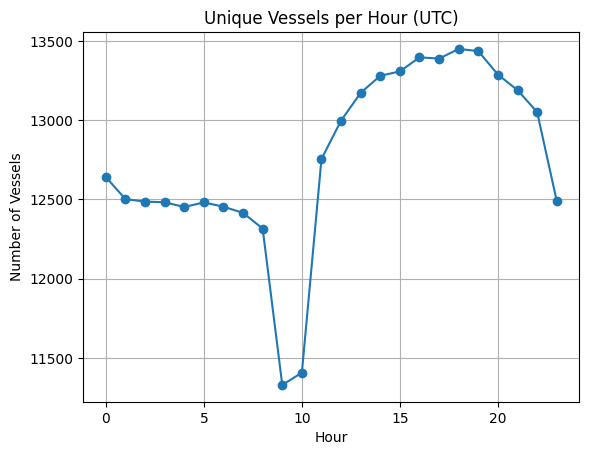

In [23]:
#First Analysis: When are boats out? Display a line graph where your x-axis is the hour of the day, and the y-axis is the number of unique vessels out at that hour. Hint: the MMSI column is a great way to identity a unique vessel. What time (UTC) saw the most boats out on the water? And the least? Does this track with what you could expect?
df['hour'] = df.index.hour
boats_per_hour = df.groupby('hour')['mmsi'].nunique()
import matplotlib.pyplot as plt
boats_per_hour.plot(kind='line', marker='o')
plt.title("Unique Vessels per Hour (UTC)")
plt.xlabel("Hour")
plt.ylabel("Number of Vessels")
plt.grid()
plt.show()

In [29]:
#Second Analysis: let's look at a specific boat, the Henry Hudson (MMSI: 366651000). The owner of the boat has asked us how long the boat engines were active for that day.

df = df.sort_index()

# filter the boat Henry Hudson
boat = df[df['mmsi']== 366651000].copy()
boat = boat.sort_index()

#calculate accelaration (change in sog)
boat['acceleration'] = boat['sog'].diff()

# Caculate duration(time difference)
boat ['duration'] = boat.index.to_series().diff()

#Filter when engines are active - this assumes the boat always coasts to a stop
# and doesn't fire engine in reverse.
active = boat[boat['acceleration']> 0]

# Total active time
total_active_time = active['duration'].sum()
print(total_active_time)


0 days 08:03:24
